<a href="https://colab.research.google.com/github/anurikaemmanuellajohn-crypto/-nigerian-ai-detection-dissertation/blob/main/nigerian_ai_detection_analysis_MAIN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Cell 1: Install and Load Libraries
This cell installs necessary Python libraries for data analysis, NLP, and machine learning, and downloads a spaCy English language model.

In [3]:
!pip install nltk spacy pandas openpyxl matplotlib seaborn scikit-learn transformers torch
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 98.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


### Cell 2: Upload Dataset
This cell prompts the user to upload the `Master_Dataset_700.xlsx` file, which contains the raw data for analysis.

In [4]:
from google.colab import files
uploaded = files.upload()

Saving Master_Dataset_700.xlsx to Master_Dataset_700.xlsx


### Cell 3: Load and Summarize Data
This cell loads the uploaded Excel file into a pandas DataFrame and displays the total number of samples, as well as the count of human and AI-generated texts.

In [5]:
import pandas as pd
df = pd.read_excel('Master_Dataset_700.xlsx', sheet_name='Combined_For_Analysis')
print('Total samples:', len(df))
print('Human texts:', len(df[df['label']==0]))
print('AI texts:', len(df[df['label']==1]))

Total samples: 704
Human texts: 354
AI texts: 350


### Cell 4: Calculate Burstiness
This cell downloads NLTK packages and then defines a function to calculate the 'burstiness' of text based on the standard deviation of sentence lengths. It applies this function to the content column and prints the average burstiness for human and AI texts.

In [21]:
import nltk
import numpy as np
nltk.download('punkt')
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize

def calculate_burstiness(text):
    if pd.isna(text) or len(str(text)) < 10:
        return 0
    sentences = sent_tokenize(str(text))
    if len(sentences) < 2:
        return 0
    lengths = [len(s.split()) for s in sentences]
    return np.std(lengths)

df['burstiness'] = df['content'].apply(calculate_burstiness)
print('Burstiness calculated successfully')
print(df.groupby('label')['burstiness'].mean())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


Burstiness calculated successfully
label
0    12.541669
1     7.010341
Name: burstiness, dtype: float64


### Cell 5: Calculate Lexical Density
This cell loads the spaCy English model and defines a function to calculate the lexical density of text (ratio of content words to total words). It applies this function to the content column and prints the average lexical density for human and AI texts.

In [7]:
import spacy
nlp = spacy.load('en_core_web_sm')

def calculate_lexical_density(text):
    if pd.isna(text) or len(str(text)) < 10:
        return 0
    doc = nlp(str(text)[:10000])
    content_pos = {'NOUN', 'VERB', 'ADJ', 'ADV'}
    total = len([t for t in doc if not t.is_space])
    content = len([t for t in doc if t.pos_ in content_pos])
    if total == 0:
        return 0
    return content / total

df['lexical_density'] = df['content'].apply(calculate_lexical_density)
print('Lexical density calculated successfully')
print(df.groupby('label')['lexical_density'].mean())

Lexical density calculated successfully
label
0    0.441790
1    0.439545
Name: lexical_density, dtype: float64


### Cell 6: Calculate Perplexity
This cell loads a pre-trained GPT-2 tokenizer and model to calculate the 'perplexity' of text, a measure of how well a probability model predicts a sample. It applies this function to the content column and prints the average perplexity for human and AI texts.

In [8]:
from transformers import GPT2LMHeadModel, GPT2TokenizerFast
import torch

tokenizer = GPT2TokenizerFast.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')
model.eval()

def calculate_perplexity(text):
    if pd.isna(text) or len(str(text)) < 10:
        return 0
    try:
        inputs = tokenizer(str(text)[:1024], return_tensors='pt', truncation=True)
        with torch.no_grad():
            outputs = model(**inputs, labels=inputs['input_ids'])
        return torch.exp(outputs.loss).item()
    except:
        return 0

df['perplexity'] = df['content'].apply(calculate_perplexity)
print('Perplexity calculated successfully')
print(df.groupby('label')['perplexity'].mean())


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Perplexity calculated successfully
label
0    36.129513
1    32.223422
Name: perplexity, dtype: float64


### Cell 7: Visualize Feature Distributions
This cell generates box plots comparing the distributions of perplexity, burstiness, and lexical density between human and AI-generated texts. It saves the plot as `feature_comparison.png`.

/tmp/ipykernel_18708/2838081314.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='perplexity', ax=axes[0], palette='Set2')
/tmp/ipykernel_18708/2838081314.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='burstiness', ax=axes[1], palette='Set2')
/tmp/ipykernel_18708/2838081314.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='lexical_density', ax=axes[2], palette='Set2')


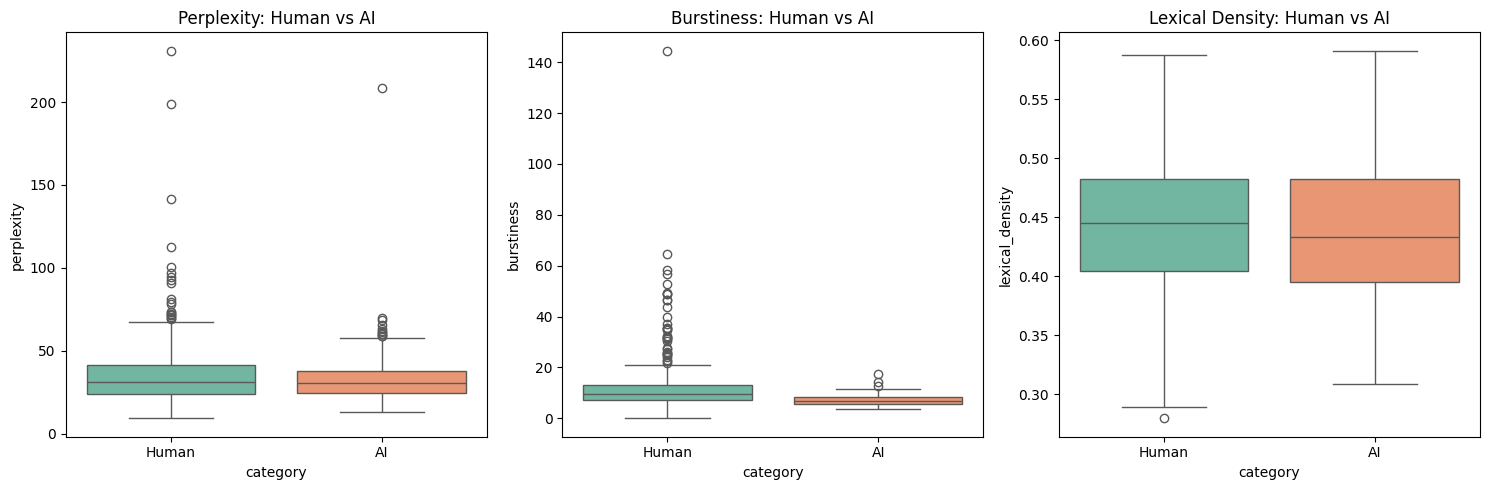

Chart saved successfully


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
df['category'] = df['label'].map({0: 'Human', 1: 'AI'})

sns.boxplot(data=df, x='category', y='perplexity', ax=axes[0], palette='Set2')
axes[0].set_title('Perplexity: Human vs AI')

sns.boxplot(data=df, x='category', y='burstiness', ax=axes[1], palette='Set2')
axes[1].set_title('Burstiness: Human vs AI')

sns.boxplot(data=df, x='category', y='lexical_density', ax=axes[2], palette='Set2')
axes[2].set_title('Lexical Density: Human vs AI')

plt.tight_layout()
plt.savefig('feature_comparison.png', dpi=150)
plt.show()
print('Chart saved successfully')

### Cell 8: Download Feature Comparison Plot
This cell downloads the `feature_comparison.png` image generated in the previous step.

In [10]:
from google.colab import files
files.download('feature_comparison.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Cell 9: Train and Evaluate Classification Models
This cell prepares the data by selecting calculated features and labels, then splits it into training and testing sets. It trains and evaluates Support Vector Machine (SVM) and Random Forest classifiers, printing their accuracy, precision, and recall scores.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score

features = df[['perplexity', 'burstiness', 'lexical_density']].fillna(0)
labels = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    features, labels, test_size=0.2, random_state=42
)

svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

print('=== SVM RESULTS ===')
print('Accuracy:', round(accuracy_score(y_test, svm_pred)*100, 1), '%')
print('Precision:', round(precision_score(y_test, svm_pred)*100, 1), '%')
print('Recall:', round(recall_score(y_test, svm_pred)*100, 1), '%')

print()
print('=== RANDOM FOREST RESULTS ===')
print('Accuracy:', round(accuracy_score(y_test, rf_pred)*100, 1), '%')
print('Precision:', round(precision_score(y_test, rf_pred)*100, 1), '%')
print('Recall:', round(recall_score(y_test, rf_pred)*100, 1), '%')

=== SVM RESULTS ===
Accuracy: 68.8 %
Precision: 56.5 %
Recall: 92.9 %

=== RANDOM FOREST RESULTS ===
Accuracy: 73.0 %
Precision: 62.5 %
Recall: 80.4 %


### Cell 10: Save and Download Dataset with Features
This cell saves the DataFrame, which now includes the calculated features (perplexity, burstiness, lexical density), to an Excel file named `Dataset_With_Features.xlsx` and then downloads it.

In [12]:
df.to_excel('Dataset_With_Features.xlsx', index=False)
from google.colab import files
files.download('Dataset_With_Features.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Cell 11: Load Dataset from GitHub
This cell loads the `Dataset_With_Features.xlsx` file directly from a GitHub repository into a pandas DataFrame. It then prints the number of rows and column names to verify successful loading.

In [13]:
import pandas as pd

url = 'https://raw.githubusercontent.com/anurikaemmanuellajohn-crypto/-nigerian-ai-detection-dissertation/main/Dataset_With_Features.xlsx'
df = pd.read_excel(url)
print('Loaded successfully:', len(df), 'rows')
print('Columns:', df.columns.tolist())

Loaded successfully: 704 rows
Columns: ['ID', 'label', 'content', 'word_count', 'source_type', 'burstiness', 'lexical_density', 'perplexity', 'category']


### Cell 12: Display Data Summary and Feature Means
This cell prints the total number of samples, the count of human and AI texts, and the mean values for perplexity, burstiness, and lexical density, grouped by the `label` (human vs. AI).

In [14]:
print('Total samples:', len(df))
print('Human texts:', len(df[df['label']==0]))
print('AI texts:', len(df[df['label']==1]))
print()
print('Feature means:')
print(df.groupby('label')[['perplexity','burstiness','lexical_density']].mean())

Total samples: 704
Human texts: 354
AI texts: 350

Feature means:
       perplexity  burstiness  lexical_density
label                                         
0       36.129513   12.541669         0.441790
1       32.223422    7.010341         0.439545


### Cell 13: Generate Scatter Plot: Burstiness vs Perplexity
This cell creates and displays a scatter plot showing the relationship between 'burstiness' and 'perplexity' for both human and AI-generated texts, with different colors for each category. It saves the plot as `scatterplot_burstiness_perplexity.png`.

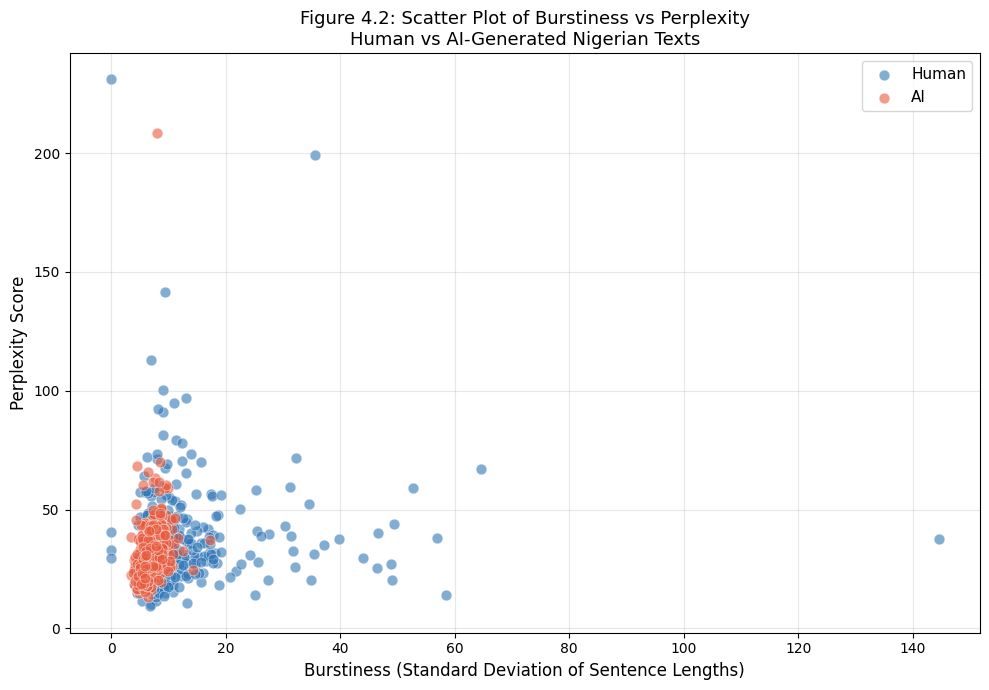

Scatterplot saved


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, 7))

colors = {0: '#2E75B6', 1: '#E8593C'}
labels = {0: 'Human', 1: 'AI'}

for label in [0, 1]:
    subset = df[df['label'] == label]
    ax.scatter(subset['burstiness'], subset['perplexity'],
               c=colors[label], label=labels[label],
               alpha=0.6, edgecolors='white', linewidth=0.5, s=60)

ax.set_xlabel('Burstiness (Standard Deviation of Sentence Lengths)', fontsize=12)
ax.set_ylabel('Perplexity Score', fontsize=12)
ax.set_title('Figure 4.2: Scatter Plot of Burstiness vs Perplexity\nHuman vs AI-Generated Nigerian Texts', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scatterplot_burstiness_perplexity.png', dpi=150)
plt.show()
print('Scatterplot saved')

### Cell 14: Generate Feature Correlation Heatmaps
This cell generates two heatmaps side-by-side, visualizing the correlations between perplexity, burstiness, and lexical density for human texts and AI-generated texts separately. It saves the plot as `heatmap_feature_correlations.png`.

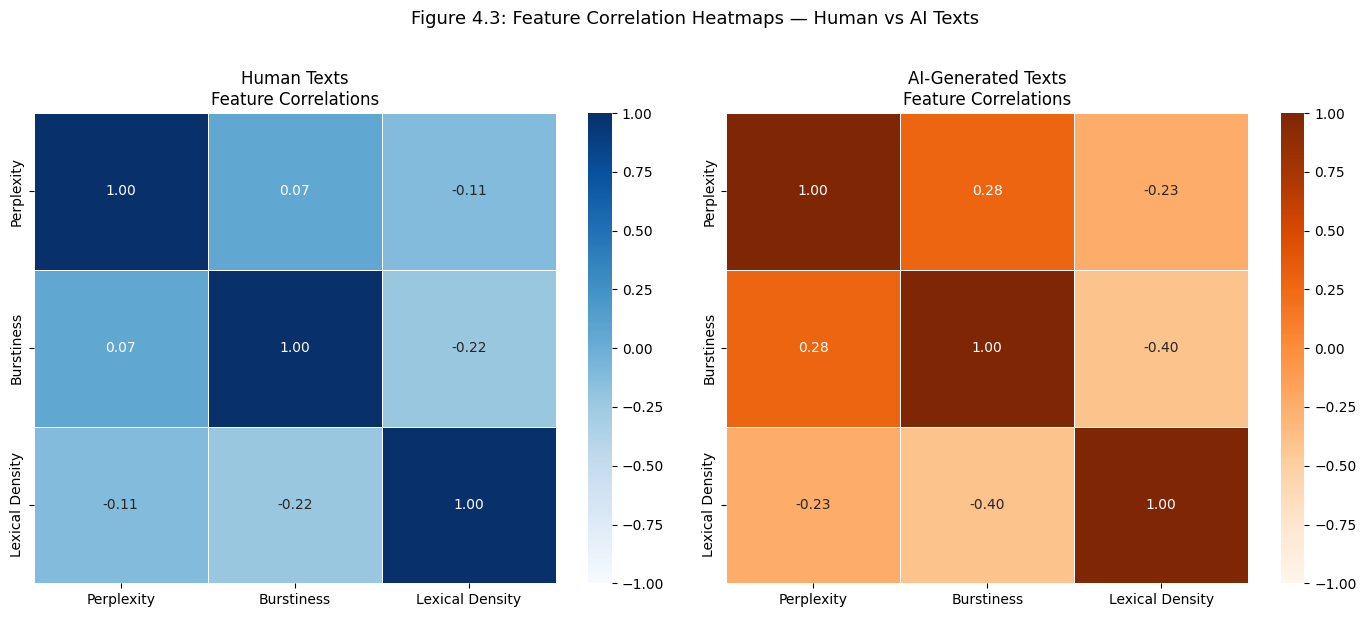

Heatmap saved


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

human_df = df[df['label'] == 0][['perplexity', 'burstiness', 'lexical_density']]
ai_df = df[df['label'] == 1][['perplexity', 'burstiness', 'lexical_density']]

human_corr = human_df.corr()
ai_corr = ai_df.corr()

feature_labels = ['Perplexity', 'Burstiness', 'Lexical Density']

sns.heatmap(human_corr, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=feature_labels, yticklabels=feature_labels,
            ax=axes[0], vmin=-1, vmax=1, linewidths=0.5)
axes[0].set_title('Human Texts\nFeature Correlations', fontsize=12)

sns.heatmap(ai_corr, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=feature_labels, yticklabels=feature_labels,
            ax=axes[1], vmin=-1, vmax=1, linewidths=0.5)
axes[1].set_title('AI-Generated Texts\nFeature Correlations', fontsize=12)

fig.suptitle('Figure 4.3: Feature Correlation Heatmaps — Human vs AI Texts', fontsize=13, y=1.02)

plt.tight_layout()
plt.savefig('heatmap_feature_correlations.png', dpi=150)
plt.show()
print('Heatmap saved')

### Cell 15: Save and Download Plots
This cell saves and downloads the previously generated scatter plot (`scatterplot_burstiness_perplexity.png`) and the feature correlation heatmaps (`heatmap_feature_correlations.png`). Note: The `plt.savefig` calls here are redundant as the plots were already saved in the respective previous cells.

In [17]:
import matplotlib.pyplot as plt

# Save scatterplot
plt.savefig('/content/scatterplot_burstiness_perplexity.png', dpi=150, bbox_inches='tight')
plt.savefig('/content/heatmap_feature_correlations.png', dpi=150, bbox_inches='tight')

# Download
from google.colab import files
files.download('/content/scatterplot_burstiness_perplexity.png')
files.download('/content/heatmap_feature_correlations.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<Figure size 640x480 with 0 Axes>

### Cell 16: Re-generate and Save Scatter Plot
This cell re-generates the scatter plot of 'burstiness' vs 'perplexity' for human and AI texts, similar to cell `zl_9KAfB2lAi`, and saves it as `/content/scatterplot.png`.

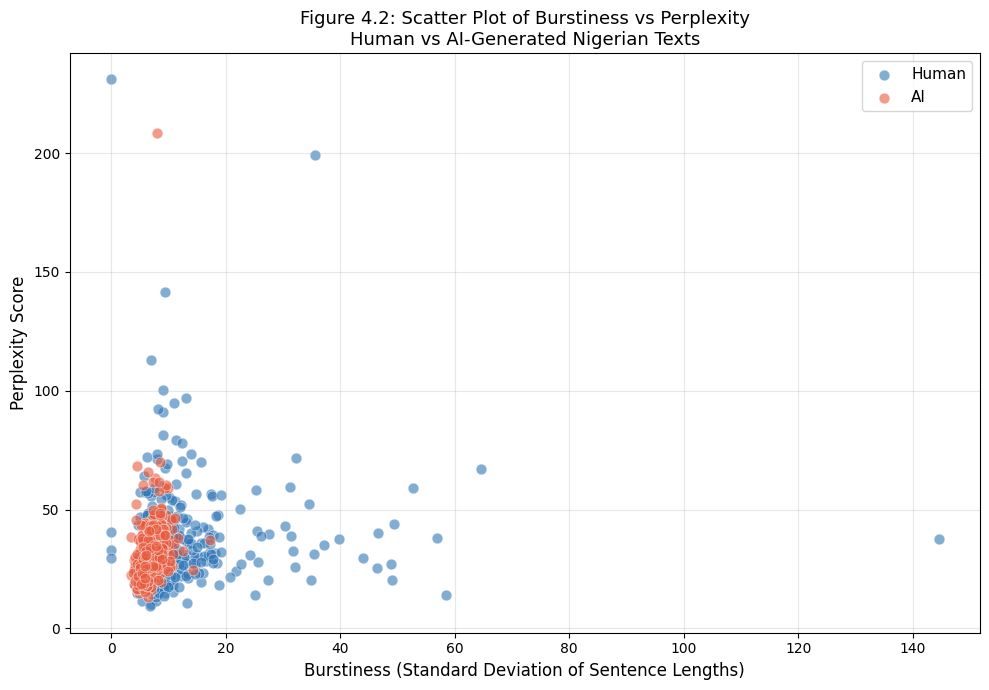

Scatterplot saved successfully


In [18]:
import matplotlib.pyplot as plt
import numpy as np

fig, ax = plt.subplots(figsize=(10, 7))

colors = {0: '#2E75B6', 1: '#E8593C'}
labels_map = {0: 'Human', 1: 'AI'}

for label in [0, 1]:
    subset = df[df['label'] == label]
    ax.scatter(subset['burstiness'], subset['perplexity'],
               c=colors[label], label=labels_map[label],
               alpha=0.6, edgecolors='white', linewidth=0.5, s=60)

ax.set_xlabel('Burstiness (Standard Deviation of Sentence Lengths)', fontsize=12)
ax.set_ylabel('Perplexity Score', fontsize=12)
ax.set_title('Figure 4.2: Scatter Plot of Burstiness vs Perplexity\nHuman vs AI-Generated Nigerian Texts', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('/content/scatterplot.png', dpi=150, bbox_inches='tight')
plt.show()
print('Scatterplot saved successfully')

### Cell 17: Re-generate and Save Feature Heatmap
This cell re-generates the feature correlation heatmaps for human and AI texts, similar to cell `ovTT4pbq2k9c`, and saves it as `/content/heatmap.png`.

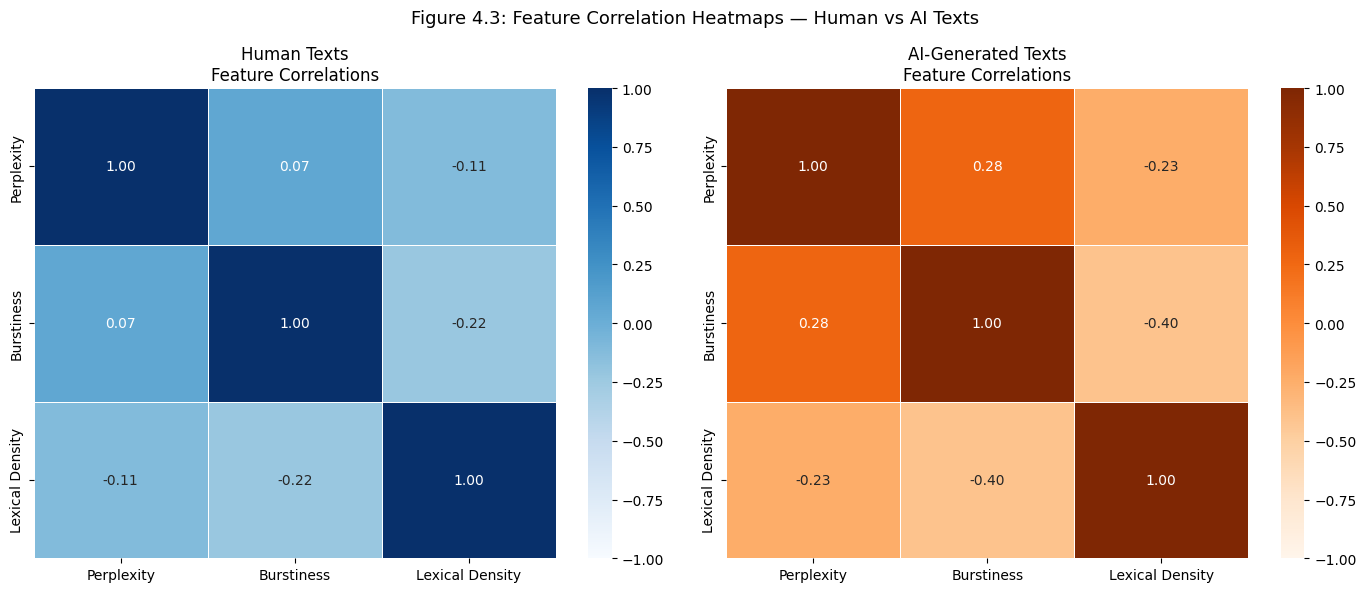

Heatmap saved successfully


In [19]:
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

human_df = df[df['label'] == 0][['perplexity', 'burstiness', 'lexical_density']]
ai_df = df[df['label'] == 1][['perplexity', 'burstiness', 'lexical_density']]
feature_labels = ['Perplexity', 'Burstiness', 'Lexical Density']

sns.heatmap(human_df.corr(), annot=True, fmt='.2f', cmap='Blues',
            xticklabels=feature_labels, yticklabels=feature_labels,
            ax=axes[0], vmin=-1, vmax=1, linewidths=0.5)
axes[0].set_title('Human Texts\nFeature Correlations', fontsize=12)

sns.heatmap(ai_df.corr(), annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=feature_labels, yticklabels=feature_labels,
            ax=axes[1], vmin=-1, vmax=1, linewidths=0.5)
axes[1].set_title('AI-Generated Texts\nFeature Correlations', fontsize=12)

fig.suptitle('Figure 4.3: Feature Correlation Heatmaps — Human vs AI Texts', fontsize=13)
plt.tight_layout()
plt.savefig('/content/heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heatmap saved successfully')